In [1]:
import pandas as pd
import numpy as np
np.set_printoptions(precision=6, suppress=True)
from sklearn.utils import shuffle
from sklearn import linear_model

In [2]:
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.ticker import (LinearLocator, MultipleLocator, FormatStrFormatter)
from matplotlib.dates import MONDAY
from matplotlib.dates import MonthLocator, WeekdayLocator, DateFormatter
from matplotlib import gridspec
from pandas.plotting import register_matplotlib_converters
register_matplotlib_converters()
%matplotlib inline

In [3]:
plt.rcParams['figure.figsize'] = ((8/2.54), (6/2.54))
plt.rcParams["font.family"] = "Arial"
plt.rcParams["mathtext.default"] = "rm"
plt.rcParams.update({'font.size': 11})
MARKER_SIZE = 15
cmap_m = ["#f4a6ad", "#f6957e", "#fccfa2", "#8de7be", "#86d6f2", "#24a9e4", "#b586e0", "#d7f293"]
cmap = ["#e94d5b", "#ef4d28", "#f9a54f", "#25b575", "#1bb1e7", "#1477a2", "#a662e5", "#c2f442"]

plt.rcParams['axes.spines.top'] = False
# plt.rcParams['axes.edgecolor'] = 
plt.rcParams['axes.linewidth'] = 1
plt.rcParams['lines.linewidth'] = 1.5
plt.rcParams['xtick.major.width'] = 1
plt.rcParams['xtick.minor.width'] = 1
plt.rcParams['ytick.major.width'] = 1
plt.rcParams['ytick.minor.width'] = 1

# Data loading

In [4]:
l = np.load('./results/2020_S/fw_dataset.npz', allow_pickle=True)
data_indices = l['data_indices']
input_data = l['input_data']
output_label = l['output_label']
INPUT_MAXS = l['INPUT_MAXS']
INPUT_MINS = l['INPUT_MINS']
OUTPUT_MAX = l['OUTPUT_MAX']
OUTPUT_MIN = l['OUTPUT_MIN']

In [5]:
input_data = input_data.astype('float32')
output_label = output_label.astype('float32')

In [6]:
input_data = input_data.reshape(input_data.shape[0], -1)

In [7]:
print(input_data.shape)
print(output_label.shape)

(363, 1296)
(363, 1)


In [8]:
print(INPUT_MAXS)
print(INPUT_MINS)

[ 42.31875  90.9425  330.1      73.335    10.006     5.057    36.58
  50.264    19.731  ]
[15.83875  4.4325  -0.5957  32.115    2.296    0.579   15.7      8.744
 11.393  ]


In [9]:
print(OUTPUT_MAX)
print(OUTPUT_MIN)

2.470441467376113
0.40038664002968494


In [10]:
data_indices, input_data, output_label = shuffle(data_indices, input_data, output_label, random_state=3101)

In [11]:
N_TRAIN = int(input_data.shape[0]*.8)
train_input = input_data[:N_TRAIN, ...]
train_label = output_label[:N_TRAIN, ...]
train_indices = data_indices[:N_TRAIN]
val_input = input_data[N_TRAIN:, ...]
val_label = output_label[N_TRAIN:, ...]
val_indices = data_indices[N_TRAIN:]

In [12]:
print(f'number of training set: {train_input.shape[0]}')
print(f'number of validation set: {val_input.shape[0]}')

number of training set: 290
number of validation set: 73


# Model construction

In [13]:
reg = linear_model.LinearRegression()

In [14]:
model = reg.fit(train_input, train_label)

# Validation data

In [15]:
l = np.load('./results/2020_W/fw_ct_dataset.npz', allow_pickle=True)
data_indices = l['data_indices']
input_data = l['input_data']
output_label = l['output_label']
INPUT_MAXS = l['INPUT_MAXS']
INPUT_MINS = l['INPUT_MINS']
OUTPUT_MAX = l['OUTPUT_MAX']
OUTPUT_MIN = l['OUTPUT_MIN']

In [16]:
input_data = input_data.astype('float32')
output_label = output_label.astype('float32')

In [17]:
input_data = input_data.reshape(input_data.shape[0], -1)

In [18]:
print(input_data.shape)
print(output_label.shape)

(456, 1296)
(456, 1)


In [19]:
print(INPUT_MAXS)
print(INPUT_MINS)

[  41.4725   99.     1313.3      78.755     7.857     4.908    35.39
   55.877    16.802 ]
[11.5    16.435  -0.5957 63.447   0.205   0.112  11.53   40.295  11.506 ]


In [20]:
print(OUTPUT_MAX)
print(OUTPUT_MIN)

1.9478683859198707
0.4452854713085716


In [21]:
data_indices, input_data, output_label = shuffle(data_indices, input_data, output_label, random_state=3101)

In [22]:
N_TRAIN = int(input_data.shape[0]*.1/3)
N_DEV = int(input_data.shape[0]/3)
TRAIN_INDEX = [_ for _ in range(N_TRAIN)] + \
              [_ for _ in range(N_DEV, N_DEV+N_TRAIN)] + \
              [_ for _ in range(N_DEV*2, N_DEV*2+N_TRAIN)]
VAL_INDEX = [_ for _ in range(input_data.shape[0]) if _ not in TRAIN_INDEX]
train_input = input_data[TRAIN_INDEX, ...]
train_label = output_label[TRAIN_INDEX, ...]
train_indices = data_indices[TRAIN_INDEX]
val_input = input_data[VAL_INDEX, ...]
val_label = output_label[VAL_INDEX, ...]
val_indices = data_indices[VAL_INDEX]

In [23]:
print(f'number of data set: {input_data.shape[0]}')
print(f'number of training set: {train_input.shape[0]}')
print(f'number of validation set: {val_input.shape[0]}')

number of data set: 456
number of training set: 45
number of validation set: 411


# Model construction

In [24]:
pred_output = model.predict(val_input)

In [25]:
pred_output = pred_output*(OUTPUT_MAX - OUTPUT_MIN) + OUTPUT_MIN
val_label = val_label*(OUTPUT_MAX - OUTPUT_MIN) + OUTPUT_MIN

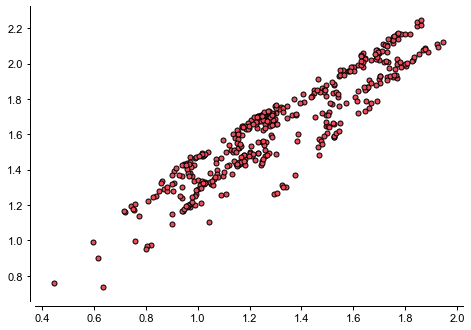

In [26]:
fig = plt.figure(figsize=((8.5/2.54*2), (6/2.54*2)))
ax0 = plt.subplot()

ax0.spines['right'].set_visible(False)
ax0.spines['left'].set_position(('outward', 5))
ax0.spines['bottom'].set_position(('outward', 5))

ax0.plot(val_label, pred_output, 'o', ms=5, mec='k', c=cmap[0])


fig.tight_layout()

In [27]:
pred_df = pd.DataFrame(val_label, index=val_indices[:, 0], columns=['label'])
pred_df['pred'] = pred_output
pred_df.index = pd.DatetimeIndex(pred_df.index)
pred_df = pred_df.sort_index()

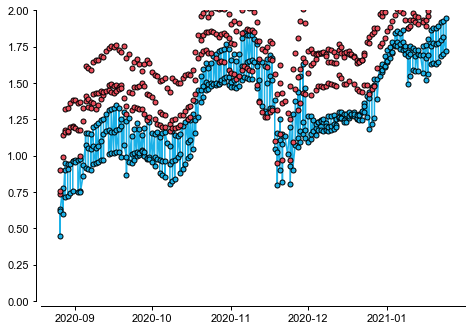

In [28]:
fig = plt.figure(figsize=((8.5/2.54*2), (6/2.54*2)))
ax0 = plt.subplot()

ax0.spines['right'].set_visible(False)
ax0.spines['left'].set_position(('outward', 5))
ax0.spines['bottom'].set_position(('outward', 5))

ax0.plot(pred_df.index, pred_df['label'], '-o', ms=5, mec='k', c=cmap[4])
ax0.plot(pred_df.index, pred_df['pred'], 'o', ms=5, mec='k', c=cmap[0])

ax0.set_ybound(0, 2)

fig.tight_layout()

In [29]:
pred_df.to_csv('./results/model_output/linreg_pre.csv')